# DSN Mart Sales Prediction
## Using Residual Correction 

## Import libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path
from scipy.optimize import linear_sum_assignment
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor


## Load the data


In [3]:
DATA_DIR = Path("/kaggle/input/datasets/oluwafemiomosule/dsn-bootcamp")


In [4]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
bigmart = pd.read_csv(DATA_DIR / "train_big_smart.csv")


In [5]:
print(train.shape)
print(test.shape)
print(bigmart.shape)


(6818, 13)
(1705, 12)
(8523, 12)


## First look at the target


In [6]:
train["total_sales"].describe()


count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

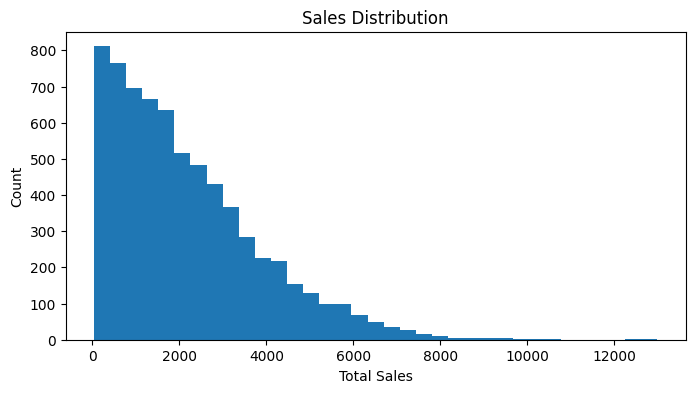

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(train["total_sales"], bins=35)
plt.title("Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Count")
plt.show()


## Check store performance


In [8]:
store_mean = (
    train.groupby("store_code")["total_sales"]
    .mean()
    .sort_values()
)

store_mean


store_code
STORE-JOR     334.435011
STORE-T5G     338.326651
STORE-HL7    1971.661954
STORE-DKU    2177.136481
STORE-YLW    2253.950690
STORE-AGY    2254.890120
STORE-OYG    2365.833656
STORE-89Z    2365.926745
STORE-9RG    2479.168098
STORE-7WS    3660.182219
Name: total_sales, dtype: float64

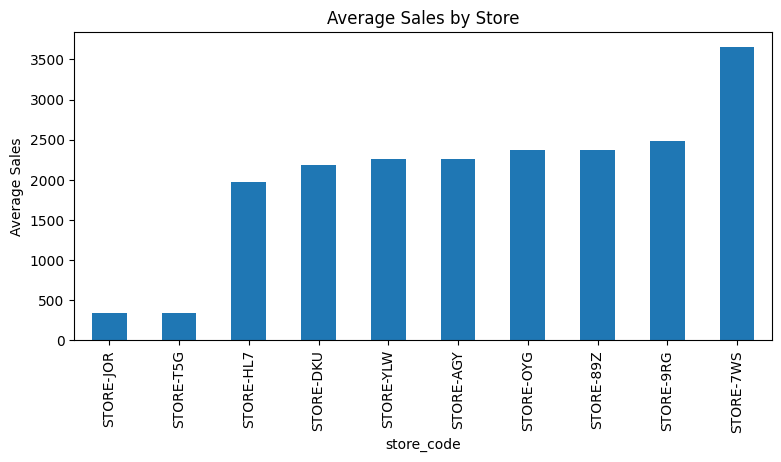

In [9]:
plt.figure(figsize=(9, 4))
store_mean.plot(kind="bar")
plt.title("Average Sales by Store")
plt.ylabel("Average Sales")
plt.show()


## Check price and sales


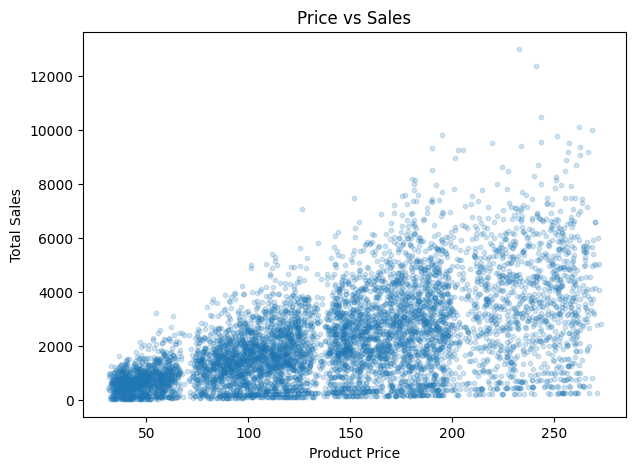

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(
    train["product_price"],
    train["total_sales"],
    alpha=0.2,
    s=10
)
plt.xlabel("Product Price")
plt.ylabel("Total Sales")
plt.title("Price vs Sales")
plt.show()


## Clean a few text fields


In [11]:
def clean_fat(value):
    value = str(value).lower().strip()

    if value in ["lf", "low fat", "low_fat"]:
        return "low fat"

    if value in ["reg", "regular"]:
        return "regular"

    return value


In [12]:
bigmart["age"] = 2032 - bigmart["Outlet_Establishment_Year"]
bigmart["category"] = bigmart["Item_Type"].str.lower().str.strip()
bigmart["fat_clean"] = bigmart["Item_Fat_Content"].apply(clean_fat)


In [13]:
combined = pd.concat([train, test], ignore_index=True)

combined["category"] = (
    combined["product_category"]
    .str.lower()
    .str.strip()
)

combined["fat_clean"] = (
    combined["fat_content"]
    .apply(clean_fat)
)


## Match the stores


In [14]:
store_table = bigmart[
    [
        "Outlet_Identifier",
        "age",
        "Outlet_Location_Type"
    ]
].drop_duplicates()

store_table["tier"] = (
    store_table["Outlet_Location_Type"]
    .str.replace(" ", "_", regex=False)
)


In [15]:
store_lookup = store_table.set_index(
    ["age", "tier"]
)["Outlet_Identifier"]


In [16]:
combined["source_store"] = [
    store_lookup.loc[(age, tier)]
    for age, tier in zip(
        combined["store_age_years"],
        combined["store_location_tier"]
    )
]


In [17]:
combined[
    ["store_code", "source_store"]
].drop_duplicates()


,store_code,source_store
0,STORE-AGY,OUT013
1,STORE-YLW,OUT046
2,STORE-89Z,OUT049
3,STORE-7WS,OUT027
4,STORE-9RG,OUT035
7,STORE-HL7,OUT018
9,STORE-JOR,OUT010
10,STORE-T5G,OUT019
11,STORE-OYG,OUT017
14,STORE-DKU,OUT045


## Build product fingerprints


In [18]:
dsn_products = (
    combined.groupby("product_code")
    .agg(
        category=("category", "first"),
        fat=("fat_clean", lambda x: x.mode().iat[0]),
        price=("product_price", "median"),
        weight=("product_weight_kg", "median"),
        stores=("source_store", lambda x: "|".join(sorted(x)))
    )
    .reset_index()
)


In [19]:
source_products = (
    bigmart.groupby("Item_Identifier")
    .agg(
        category=("category", "first"),
        fat=("fat_clean", lambda x: x.mode().iat[0]),
        price=("Item_MRP", "median"),
        weight=("Item_Weight", "median"),
        stores=("Outlet_Identifier", lambda x: "|".join(sorted(x)))
    )
    .reset_index()
)


## Match products


In [20]:
product_map = {}


In [21]:
for key, left_group in dsn_products.groupby(
    ["category", "fat", "stores"]
):

    right_group = source_products[
        (source_products["category"] == key[0]) &
        (source_products["fat"] == key[1]) &
        (source_products["stores"] == key[2])
    ]

    price_gap = (
        left_group["price"].to_numpy()[:, None]
        - right_group["price"].to_numpy()[None, :]
    )

    weight_gap = (
        left_group["weight"].to_numpy()[:, None]
        - right_group["weight"].to_numpy()[None, :]
    )

    cost = (price_gap / 3.0) ** 2

    cost = cost + np.where(
        np.isfinite(weight_gap),
        (weight_gap / 0.25) ** 2,
        0
    )

    left_index, right_index = linear_sum_assignment(cost)

    for i, j in zip(left_index, right_index):
        product_map[
            left_group.iloc[i]["product_code"]
        ] = right_group.iloc[j]["Item_Identifier"]


In [22]:
print("Products matched:", len(product_map))


Products matched: 1559


In [23]:
combined["source_product"] = (
    combined["product_code"]
    .map(product_map)
)


## Recover original sales


In [24]:
matched = combined.merge(
    bigmart[
        [
            "Item_Identifier",
            "Outlet_Identifier",
            "Item_Outlet_Sales",
            "Item_MRP",
            "Item_Visibility",
            "Item_Weight"
        ]
    ],
    left_on=[
        "source_product",
        "source_store"
    ],
    right_on=[
        "Item_Identifier",
        "Outlet_Identifier"
    ],
    how="left",
    validate="one_to_one",
    sort=False
)


In [25]:
print(
    "Missing recovered sales:",
    matched["Item_Outlet_Sales"].isna().sum()
)


Missing recovered sales: 0


## Measure the recovered baseline


In [26]:
base_train = (
    matched.iloc[:len(train)]
    ["Item_Outlet_Sales"]
    .to_numpy()
)

base_test = (
    matched.iloc[len(train):]
    ["Item_Outlet_Sales"]
    .to_numpy()
)

target = train["total_sales"].to_numpy()


In [27]:
base_rmse = np.sqrt(
    mean_squared_error(
        target,
        base_train
    )
)

print("Baseline RMSE:", base_rmse)


Baseline RMSE: 78.5534202581423


## Look at the residual


In [28]:
residual = target - base_train


In [29]:
pd.Series(residual).describe()


count    6818.000000
mean        0.605326
std        78.556849
min      -415.068800
25%       -33.917600
50%        -0.128000
75%        35.074750
max       466.147200
dtype: float64

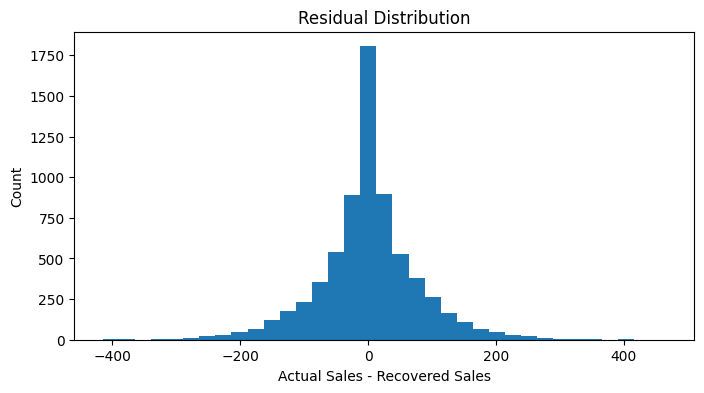

In [30]:
plt.figure(figsize=(8, 4))
plt.hist(residual, bins=35)
plt.title("Residual Distribution")
plt.xlabel("Actual Sales - Recovered Sales")
plt.ylabel("Count")
plt.show()


## Prepare residual-model features


In [31]:
train_model = train.copy()
test_model = test.copy()


In [32]:
train_model["base_sales"] = base_train
test_model["base_sales"] = base_test


In [33]:
train_model["price_gap"] = (
    train["product_price"].to_numpy()
    - matched.iloc[:len(train)]["Item_MRP"].to_numpy()
)

test_model["price_gap"] = (
    test["product_price"].to_numpy()
    - matched.iloc[len(train):]["Item_MRP"].to_numpy()
)


In [34]:
train_model["visibility_gap"] = (
    train["shelf_visibility"].to_numpy()
    - matched.iloc[:len(train)]["Item_Visibility"].to_numpy()
)

test_model["visibility_gap"] = (
    test["shelf_visibility"].to_numpy()
    - matched.iloc[len(train):]["Item_Visibility"].to_numpy()
)


In [35]:
train_model["weight_gap"] = (
    train["product_weight_kg"].to_numpy()
    - matched.iloc[:len(train)]["Item_Weight"].to_numpy()
)

test_model["weight_gap"] = (
    test["product_weight_kg"].to_numpy()
    - matched.iloc[len(train):]["Item_Weight"].to_numpy()
)


In [36]:
features = [
    "product_code",
    "fat_content",
    "product_category",
    "store_code",
    "store_age_years",
    "store_size",
    "store_location_tier",
    "store_format",
    "product_price",
    "product_weight_kg",
    "shelf_visibility",
    "base_sales",
    "price_gap",
    "visibility_gap",
    "weight_gap"
]


In [37]:
categorical_columns = [
    "product_code",
    "fat_content",
    "product_category",
    "store_code",
    "store_size",
    "store_location_tier",
    "store_format"
]


In [38]:
X = train_model[features].copy()
X_test = test_model[features].copy()

for column in categorical_columns:
    X[column] = X[column].astype(str)
    X_test[column] = X_test[column].astype(str)


## Cross validation for the residual model


In [39]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


In [40]:
oof_residual = np.zeros(len(train))


In [41]:
for fold, (fit_index, val_index) in enumerate(cv.split(X)):

    model = CatBoostRegressor(
        iterations=300,
        depth=4,
        learning_rate=0.02,
        loss_function="RMSE",
        l2_leaf_reg=20,
        verbose=False,
        random_seed=100 + fold
    )

    model.fit(
        X.iloc[fit_index],
        residual[fit_index],
        cat_features=categorical_columns
    )

    oof_residual[val_index] = model.predict(
        X.iloc[val_index]
    )


I tested different residual weights.

A large residual correction made validation worse, so I kept the correction very small.


In [42]:
for residual_weight in [0, 0.05, 0.10, 0.20, 0.50, 1.00]:

    corrected = (
        base_train
        + residual_weight * oof_residual
    )

    score = np.sqrt(
        mean_squared_error(
            target,
            corrected
        )
    )

    print(
        residual_weight,
        round(score, 5)
    )


0 78.55342
0.05 78.56494
0.1 78.57676
0.2 78.60133
0.5 78.68234
1.0 78.84168


## Train the residual model on all training rows


In [43]:
final_residual_model = CatBoostRegressor(
    iterations=300,
    depth=4,
    learning_rate=0.02,
    loss_function="RMSE",
    l2_leaf_reg=20,
    verbose=False,
    random_seed=123
)


In [44]:
final_residual_model.fit(
    X,
    residual,
    cat_features=categorical_columns
)


CatBoostRegressor(depth=4, iterations=300, l2_leaf_reg=20, learning_rate=0.02, loss_function='RMSE', random_seed=123, verbose=False)

In [45]:
test_residual = (
    final_residual_model
    .predict(X_test)
)


## Final prediction


In [46]:
residual_weight = 0.05


In [47]:
final_prediction = (
    base_test
    + residual_weight * test_residual
)


In [48]:
final_prediction = np.maximum(
    final_prediction,
    0
)


In [49]:
final_prediction[:10]


array([1937.46659749, 4229.28980136, 4447.73054478, 2570.63983682,
       3912.28493383,  149.81404166, 3916.26611238, 1464.76969944,
        617.8486784 , 1470.13234128])

## Submission


In [50]:
submission = pd.DataFrame({
    "id": test["id"],
    "total_sales": final_prediction
})


In [51]:
submission.head()


,id,total_sales
0,row_00009,1937.466597
1,row_00015,4229.289801
2,row_00019,4447.730545
3,row_00020,2570.639837
4,row_00023,3912.284934


In [52]:
submission.to_csv(
    "/kaggle/working/residual_correction_submission.csv",
    index=False
)


In [53]:
print(
    "Saved:",
    "/kaggle/working/residual_correction_submission.csv"
)


Saved: /kaggle/working/residual_correction_submission.csv
